<a href="https://colab.research.google.com/github/khushi-mahida/BASCIS_DATASCI_MACHINE-LEARNING-/blob/main/customerSegmentationFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

In [4]:
import numpy as np


In [5]:

customers = np.random.choice(['customers_'+ str(i)for i in range (1,400)],size= 1000,replace= True )
print(customers)
purchase = np.random.randint(1,1000,size=1000)
print(purchase)

['customers_335' 'customers_200' 'customers_126' 'customers_16'
 'customers_267' 'customers_4' 'customers_257' 'customers_295'
 'customers_257' 'customers_165' 'customers_338' 'customers_133'
 'customers_73' 'customers_273' 'customers_104' 'customers_334'
 'customers_233' 'customers_157' 'customers_291' 'customers_351'
 'customers_245' 'customers_134' 'customers_379' 'customers_65'
 'customers_14' 'customers_36' 'customers_342' 'customers_36'
 'customers_77' 'customers_346' 'customers_22' 'customers_13'
 'customers_291' 'customers_305' 'customers_359' 'customers_141'
 'customers_395' 'customers_369' 'customers_21' 'customers_141'
 'customers_333' 'customers_45' 'customers_313' 'customers_335'
 'customers_383' 'customers_192' 'customers_311' 'customers_380'
 'customers_142' 'customers_40' 'customers_50' 'customers_67'
 'customers_134' 'customers_384' 'customers_148' 'customers_99'
 'customers_304' 'customers_210' 'customers_131' 'customers_298'
 'customers_361' 'customers_337' 'customer

In [6]:
data = pd.DataFrame({'customer_Id':customers,'amount':purchase})
print(data)

       customer_Id  amount
0    customers_335     937
1    customers_200     918
2    customers_126     169
3     customers_16     278
4    customers_267     616
..             ...     ...
995  customers_196     356
996  customers_102     349
997  customers_273      52
998  customers_313     315
999   customers_76     133

[1000 rows x 2 columns]


In [7]:
from sklearn.cluster import KMeans
kmeans =KMeans(n_clusters=4)
data['cluster']=kmeans.fit_predict(data[['amount']])

In [8]:
from sklearn.metrics import silhouette_score

kmeans_silhouette = silhouette_score(
    data['amount'],      # Features
    data['cluster']        #label
)

print("The KMeans Silhouette Score is:", kmeans_silhouette)

The KMeans Silhouette Score is: 0.5783483874157579


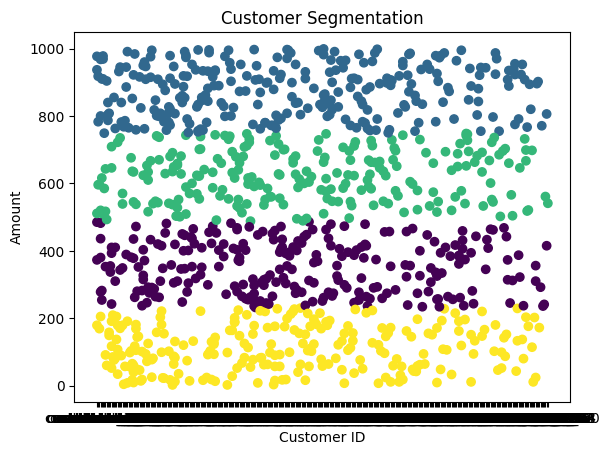

In [14]:
import matplotlib.pyplot as plt

plt.scatter(
    data['customer_Id'],
    data['amount'],
    c=data['cluster']
)

plt.xlabel('Customer ID')
plt.ylabel('Amount')
plt.title('Customer Segmentation')
plt.show()

In [13]:
data.head()

,customer_Id,amount,cluster
0,customers_335,937,1
1,customers_200,918,1
2,customers_126,169,3
3,customers_16,278,0
4,customers_267,616,2


In [18]:
import plotly.express as px

fig = px.scatter(
    data,
    x='customer_Id',
    y='amount',
    color='cluster',
    title='Customer Segmentation',
    labels={
        'customer_Id': 'Customer ID',
        'amount': 'Purchase Amount'
    }
)

fig.show()

In [22]:
def get_cluster(customer_id, data):
    result = data[data['customer_Id'] == customer_id]['cluster']

    if len(result) == 0:
        return "Customer not found"

    return result.values[0]


customer_id = 'Customer_2'

cluster = get_cluster(customer_id, data)

print(f'Customer {customer_id} belongs to cluster {cluster}')

Customer Customer_2 belongs to cluster Customer not found


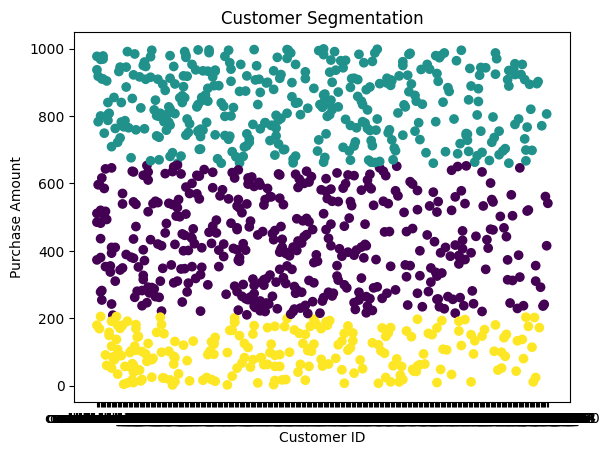

In [27]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
data['cluster'] = agg.fit_predict(data[['amount']])
plt.scatter(data['customer_Id'], data['amount'], c=data['cluster'])
plt.xlabel('Customer ID')
plt.ylabel('Purchase Amount')
plt.title('Customer Segmentation')
plt.show()

fig = px.scatter(data, x='customer_Id', y='amount', color='cluster',
                    title='Customer Segmentation', labels={'customer_Id': 'Customer ID', 'amount': 'Purchase Amount'})
fig.show()


In [29]:

from sklearn.metrics import silhouette_score

agg_silhouette = silhouette_score(data[['amount']], data['cluster'])
print(f'Agglomerative Silhouette Score: {agg_silhouette}')

Agglomerative Silhouette Score: 0.5521450145311095
